<a href="https://colab.research.google.com/github/MarcosRigal/AP/blob/main/catfish_sales_rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Utilizar Keras para construir y entrenar redes LSTM / GRU con series temporales

En este cuaderno vamos a usar **Keras** (TensorFlow) para predecir una serie temporal de **ventas de peces gato** (en miles de libras, frecuencia mensual).

Seguimos la misma estructura que en el ejemplo de pasajeros de aerolíneas, pero adaptado a un nuevo dataset y ampliado con un pequeño _grid‑search_ de hiperparámetros.

## Descripción del problema
Se dispone de una serie temporal:
* **Catfish** – ventas de peces gato (k£/mes)

Nuestro objetivo es aprender a responder a la pregunta:
> "Dado el número de ventas de este mes, ¿cuál será la cifra de ventas el mes que viene?"

Trabajaremos con la estrategia **`one‑step ahead`** (predecimos _t+1_ usando los valores de _t_).

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, InputLayer

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, os, math, warnings

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import kagglehub

warnings.filterwarnings('ignore', category=FutureWarning)
tf.random.set_seed(7)
np.random.seed(7)

## Cargar y explorar el dataset
Usaremos **KaggleHub** para descargar la última versión del dataset *Catfish Sales*.

In [8]:
# Descargar (la primera vez tardará unos segundos)
path = kagglehub.dataset_download('yekahaaagayeham/time-series-toy-data-set')

# Buscar CSV
csv_files = glob.glob(os.path.join(path, '*.csv'))
if not csv_files:
    raise FileNotFoundError('No se encontró ningún CSV en el dataset')
df = pd.read_csv(csv_files[2])
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print('Primeras filas:')
display(df.head())

Primeras filas:


,Total
Date,
1986-01-01,9034
1986-02-01,9596
1986-03-01,10558
1986-04-01,9002
1986-05-01,9239


### Visualización de la serie
A continuación representamos ambas series para hacernos una idea de su tendencia y estacionalidad.

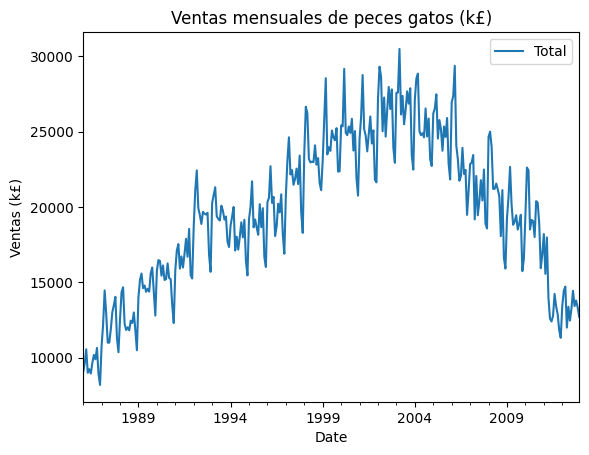

In [10]:
df.plot(title='Ventas mensuales de peces gatos (k£)')
plt.ylabel('Ventas (k£)')
plt.show()

## Preparación de los datos
Las redes recurrentes suelen ser sensibles a la escala de los datos, por lo que normalizaremos cada serie al rango **[0, 1]** usando `MinMaxScaler`.

In [12]:
target_col = 'Total'

values = df[target_col].values.astype('float32').reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(values)

print('Dataset shape:', dataset.shape)

Dataset shape: (324, 1)


### División train / test
Seguiremos la misma proporción **67 % / 33 %** que el ejemplo original.

In [13]:
train_size = int(len(dataset) * 0.67)
train, test = dataset[:train_size], dataset[train_size:]
print(f'Train: {train.shape}, Test: {test.shape}')

Train: (217, 1), Test: (107, 1)


### Función `create_dataset`
Convierten un array 1‑D en pares **(X, y)** para supervisar una RNN. Usaremos un parámetro `look_back` que indica cuántos pasos atrás queremos alimentar al modelo (por defecto, 1).

In [14]:
def create_dataset(series, look_back=1):
    X, y = [], []
    for i in range(len(series) - look_back):
        X.append(series[i:i + look_back, 0])
        y.append(series[i + look_back, 0])
    X = np.array(X).reshape((-1, look_back, 1))
    y = np.array(y)
    return X, y

look_back = 1
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

print('trainX shape:', trainX.shape, 'trainY shape:', trainY.shape)

trainX shape: (216, 1, 1) trainY shape: (216,)


El método anterior ya devuelve **X** con la forma 3‑D `[samples, time steps, features]` necesaria para Keras, por lo que no necesitamos un `reshape()` adicional.

## Definición del modelo RNN
Vamos a probar dos tipos de celdas recurrentes:
* **LSTM** (Long Short‑Term Memory)
* **GRU**  (Gated Recurrent Unit)

Además exploraremos distintos tamaños de **batch**, número de **unidades** y **épocas**.

In [15]:
def build_model(cell_type='LSTM', units=32, look_back=1):
    model = Sequential()
    model.add(InputLayer(input_shape=(look_back, 1)))
    if cell_type == 'LSTM':
        model.add(LSTM(units))
    elif cell_type == 'GRU':
        model.add(GRU(units))
    else:
        raise ValueError('cell_type must be LSTM or GRU')
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

## Búsqueda de hiperparámetros
Probamos varias combinaciones y almacenamos el **RMSE** (Root Mean Squared Error) en train y test.

In [16]:
batch_sizes = [32, 64, 128]
units_list = [16, 32, 64]
cell_types = ['LSTM', 'GRU']
epochs_list = [50, 100]

results = []
total = len(batch_sizes) * len(units_list) * len(cell_types) * len(epochs_list)
comb = 0

for cell in cell_types:
    for batch in batch_sizes:
        for units in units_list:
            for epochs in epochs_list:
                comb += 1
                print(f'\n[{comb}/{total}] {cell} | batch={batch} | units={units} | epochs={epochs}')
                tf.keras.backend.clear_session()
                model = build_model(cell, units, look_back)
                model.fit(trainX, trainY, epochs=epochs, batch_size=batch, verbose=0, shuffle=False)

                # Predicciones para evaluación
                train_pred = model.predict(trainX, verbose=0)
                test_pred = model.predict(testX, verbose=0)
                # Des‑normalizar
                train_rmse = math.sqrt(mean_squared_error(scaler.inverse_transform(trainY.reshape(-1,1)),
                                                          scaler.inverse_transform(train_pred)))
                test_rmse  = math.sqrt(mean_squared_error(scaler.inverse_transform(testY.reshape(-1,1)),
                                                          scaler.inverse_transform(test_pred)))

                results.append({'cell_type': cell,
                                'batch_size': batch,
                                'units': units,
                                'epochs': epochs,
                                'train_rmse': train_rmse,
                                'test_rmse': test_rmse})
                print(f'→ Train RMSE = {train_rmse:.2f} | Test RMSE = {test_rmse:.2f}')

results_df = pd.DataFrame(results).sort_values('test_rmse')
display(results_df.head())


[1/36] LSTM | batch=32 | units=16 | epochs=50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


→ Train RMSE = 3343.65 | Test RMSE = 2949.54

[2/36] LSTM | batch=32 | units=16 | epochs=100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


→ Train RMSE = 2442.85 | Test RMSE = 2300.08

[3/36] LSTM | batch=32 | units=32 | epochs=50


...

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


→ Train RMSE = 3434.08 | Test RMSE = 3019.32

[36/36] GRU | batch=128 | units=64 | epochs=100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


→ Train RMSE = 2889.43 | Test RMSE = 2621.81


,cell_type,batch_size,units,epochs,train_rmse,test_rmse
23,GRU,32,64,100,1872.099223,2004.525068
21,GRU,32,32,100,1930.564101,2011.944457
5,LSTM,32,64,100,1956.635888,2025.412859
3,LSTM,32,32,100,2202.942237,2153.630888
22,GRU,32,64,50,2218.972059,2169.536356


### Mejor configuración
Entrenamos de nuevo usando la combinación con **menor Test RMSE** y representamos las predicciones junto con la serie original.

Mejor configuración encontrada:


,23
cell_type,GRU
batch_size,32
units,64
epochs,100
train_rmse,1872.099223
test_rmse,2004.525068


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


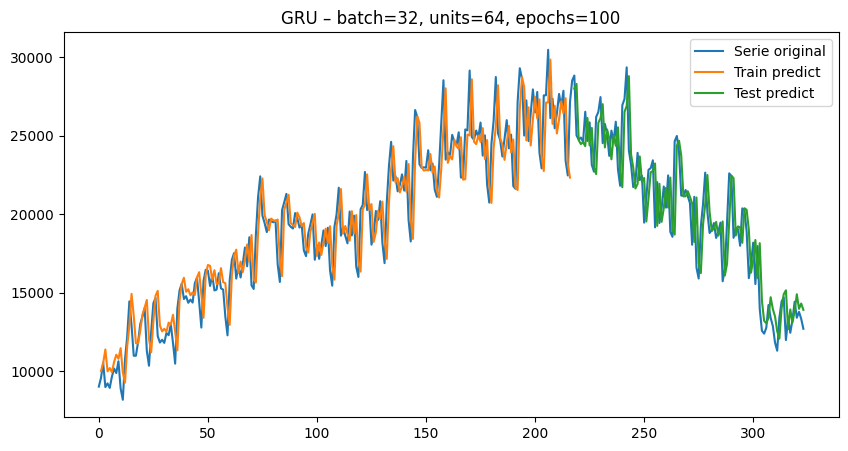

In [17]:
best = results_df.iloc[0]
print('Mejor configuración encontrada:')
display(best)

tf.keras.backend.clear_session()
best_model = build_model(best.cell_type, int(best.units), look_back)
best_model.fit(trainX, trainY,
              epochs=int(best.epochs),
              batch_size=int(best.batch_size),
              verbose=0,
              shuffle=False)

# Predicciones completas
train_pred = best_model.predict(trainX, verbose=0)
test_pred  = best_model.predict(testX, verbose=0)

# Preparar arrays para el plot desplazado
train_pred_plot = np.empty_like(dataset)
test_pred_plot  = np.empty_like(dataset)
train_pred_plot[:] = np.nan
test_pred_plot[:]  = np.nan

train_pred_plot[look_back:len(train_pred)+look_back, 0] = scaler.inverse_transform(train_pred)[:,0]
test_pred_plot[len(train_pred)+(look_back*2): len(dataset), 0] = scaler.inverse_transform(test_pred)[:,0]

# Plot final
plt.figure(figsize=(10,5))
plt.plot(scaler.inverse_transform(dataset), label='Serie original')
plt.plot(train_pred_plot, label='Train predict')
plt.plot(test_pred_plot,  label='Test predict')
plt.title(f"{best.cell_type} – batch={int(best.batch_size)}, units={int(best.units)}, epochs={int(best.epochs)}")
plt.legend()
plt.show()

## Conclusiones
* El modelo recurrente es capaz de capturar la tendencia de la serie y produce predicciones razonables.
* Cambiar hiperparámetros como el tamaño de batch o el número de neuronas puede mejorar (o empeorar) el **RMSE**.
* Para mejorar más: aumentar `look_back`, añadir más capas, usar _early‑stopping_, o incorporar ambas series como multivariante.


## Referencias
* Adaptado del tutorial [*Time Series Prediction with LSTM Recurrent Neural Networks in Python with Keras*](https://machinelearningmastery.com/time-series-prediction-lstm-recurrent-neural-networks-python-keras/).
* Dataset de ejemplo en Kaggle: *Time Series Toy Data Set*.